# 9. Análisis de contenido y sentimiento

CC3084 – Data Science, Universidad del Valle de Guatemala  
**Integrantes:** Javier Eduardo España (23361), Angel Esteban Esquit (23221), Roberto Jose Barreda (23354)

En esta sección se analiza el contenido textual y el sentimiento de los comentarios en español recolectados de YouTube. Se examina la distribución global de polaridad y se compara el sentimiento a través de las comunidades estructurales detectadas (sección 7), canales, videos y temáticas clave.


In [1]:
import json
import os
import re
from collections import Counter
from pathlib import Path

import emoji
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from networkx.algorithms.community import louvain_communities, modularity

DATA_DIR = Path('data') if Path('data').exists() else Path('../data')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

comments = pd.read_csv(DATA_DIR / 'comments_procesado.csv', encoding='utf-8-sig')
videos = pd.read_csv(DATA_DIR / 'videos_procesado.csv', encoding='utf-8-sig')

print(f'Comentarios cargados: {len(comments)}')
print(f'Videos procesados: {len(videos)}')


Comentarios cargados: 406
Videos procesados: 293


### 9.1 Herramienta y metodología de análisis de sentimiento en español

**Justificación metodológica:**
El análisis de sentimiento en redes sociales para español presenta desafíos particulares: modismos locales, negaciones compuestas, ironía, faltas ortográficas y el uso expresivo de emojis y puntuación repetida. 

Para procesar este corpus se implementa un motor de análisis léxico y basado en reglas adaptado al español, complementado con el análisis de valencia emocional de emojis (a través de `emoji`) y modificadores contextuales (negaciones, intensificadores y atenuadores). 

El analizador evalúa el `texto_original` (para preservar mayúsculas de énfasis, signos de exclamación y emojis) y calcula una puntuación continua de sentimiento normalizada en el rango [-1.0, +1.0]:
- **Positivo:** puntuación > +0.05
- **Neutro:** puntuación entre [-0.05, +0.05]
- **Negativo:** puntuación < -0.05


In [2]:
# Léxico de polaridad en español para contexto sociopolítico y de redes sociales
LEXICO_ES = {
    # Positivos / Aprobación / Apoyo
    'excelente': 2.5, 'bueno': 1.5, 'buena': 1.5, 'buenos': 1.5, 'buenas': 1.5, 'bien': 1.2,
    'gran': 1.8, 'grande': 1.2, 'gracias': 1.6, 'felicidades': 2.4, 'felicitaciones': 2.4,
    'apoyo': 1.8, 'apoyamos': 1.8, 'apoyar': 1.5, 'adelante': 1.5, 'correcto': 1.4,
    'verdad': 1.2, 'cierto': 1.2, 'esperanza': 2.0, 'exito': 2.0, 'éxito': 2.0,
    'justicia': 1.8, 'honesto': 2.0, 'honestos': 2.0, 'inteligente': 1.8,
    'valiente': 2.0, 'digno': 1.8, 'mejor': 1.5, 'mejores': 1.5, 'maravilla': 2.2,
    'genial': 2.0, 'bello': 1.8, 'hermoso': 1.8, 'trabajo': 0.8, 'avance': 1.2,
    'bendiciones': 2.0, 'bendicion': 2.0, 'dios': 1.0, 'ánimo': 1.8, 'animo': 1.8,
    'orgullo': 2.0, 'orgulloso': 2.0, 'progreso': 1.8, 'desarrollo': 1.4, 'transparencia': 1.8,
    'presidente': 0.3, 'gobierno': 0.0, 'correcto': 1.5, 'acuerdo': 1.2,

    # Negativos / Crítica / Corrupción / Indignación
    'corrupto': -2.5, 'corruptos': -2.5, 'corrupción': -2.5, 'corrupcion': -2.5,
    'robo': -2.4, 'roban': -2.4, 'robar': -2.4, 'ladron': -2.6, 'ladrones': -2.6,
    'ladrona': -2.6, 'rata': -2.8, 'ratas': -2.8, 'pacto': -1.2, 'pacto de corruptos': -3.0,
    'malo': -1.8, 'mala': -1.8, 'malos': -1.8, 'malas': -1.8, 'mal': -1.5,
    'pesimo': -2.8, 'pésimo': -2.8, 'pesima': -2.8, 'pésima': -2.8, 'ascom': -2.8, 'asco': -2.8,
    'verguenza': -2.6, 'vergüenza': -2.6, 'descaro': -2.4, 'descarados': -2.6, 'descarado': -2.4,
    'cinico': -2.4, 'cínico': -2.4, 'cinicos': -2.5, 'cínicos': -2.5, 'mentira': -2.2,
    'mentiras': -2.2, 'mentiroso': -2.4, 'mentirosos': -2.4, 'falso': -1.8, 'falsos': -1.8,
    'hipocrita': -2.4, 'hipócrita': -2.4, 'hipocritas': -2.4, 'hipócritas': -2.4,
    'hambre': -1.2, 'miseria': -2.2, 'pobreza': -1.8, 'tristeza': -1.8, 'triste': -1.5,
    'cooptacion': -2.2, 'cooptación': -2.2, 'cooptado': -2.0, 'ilegal': -2.2, 'fraude': -2.6,
    'inutil': -2.5, 'inútil': -2.5, 'inutiles': -2.5, 'inútiles': -2.5, 'estupido': -2.6,
    'basura': -2.8, 'porqueria': -2.8, 'porquería': -2.8, 'estafa': -2.5, 'estafadores': -2.6,
    'carcel': -2.0, 'cárcel': -2.0, 'preso': -1.8, 'presos': -1.8, 'impunidad': -2.6,
    'violencia': -2.2, 'muerte': -2.5, 'crimen': -2.4, 'criminales': -2.6, 'delincuente': -2.6,
    'delincuentes': -2.6, 'traidor': -2.6, 'traidores': -2.6, 'traicion': -2.6, 'traición': -2.6,
    'odio': -2.8, 'daño': -1.8, 'perjudica': -1.8, 'destruye': -2.0, 'destruccion': -2.2,
    'abuso': -2.4, 'abusos': -2.4, 'sinverguenza': -2.6, 'sinvergüenza': -2.6, 'sinvergüenzas': -2.6
}

# Modificadores de contexto
NEGACIONES_ES = {'no', 'nunca', 'jamas', 'jamás', 'tampoco', 'nada', 'ningun', 'ninguno', 'ninguna', 'sin'}
INTENSIFICADORES_ES = {'muy': 1.5, 'mucho': 1.4, 'demasiado': 1.6, 'tan': 1.3, 'sumamente': 1.8, 'totalmente': 1.6, 'completamente': 1.6, 'super': 1.5, 'súper': 1.5}
ATENUADORES_ES = {'poco': 0.5, 'algo': 0.7, 'medio': 0.6, 'apenas': 0.5, 'casi': 0.7}

# Polaridad de emojis frecuentes
EMOJI_SENTIMENT = {
    '👍': 1.5, '👏': 1.8, '❤️': 2.0, '😍': 2.0, '💪': 1.5, '🇬🇹': 1.2, '🔥': 1.2, '🎉': 1.8, '🙏': 1.5, '😊': 1.5, '😁': 1.5, '💯': 1.8,
    '🤮': -2.8, '🤢': -2.5, '😡': -2.6, '🤬': -3.0, '💩': -2.8, '🤡': -2.2, '🐀': -2.5, '🤦': -1.8, '🤦‍♂️': -1.8, '🤦‍♀️': -1.8, '👎': -2.0, '😢': -1.5, '😭': -1.5
}

def analizar_sentimiento(texto):
    if pd.isna(texto) or not str(texto).strip():
        return {'sentiment_score': 0.0, 'sentiment_cat': 'Neutro'}
    
    texto_str = str(texto)
    # Puntuación por emojis
    score_emojis = 0.0
    for ch in texto_str:
        if ch in EMOJI_SENTIMENT:
            score_emojis += EMOJI_SENTIMENT[ch]
            
    # Limpieza para tokens
    tokens = re.findall(r'\b[a-záéíóúüñ]+\b', texto_str.lower())
    
    score_palabras = 0.0
    palabras_evaluadas = 0
    
    i = 0
    while i < len(tokens):
        tok = tokens[i]
        # Multiplicador por mayúsculas en texto original
        mult_mayus = 1.2 if tok.upper() in texto_str else 1.0
        
        # Verificar bigrama
        if i < len(tokens) - 1:
            bigrama = f'{tok} {tokens[i+1]}'
            if bigrama in LEXICO_ES:
                score_palabras += LEXICO_ES[bigrama] * mult_mayus
                palabras_evaluadas += 1
                i += 2
                continue
                
        # Verificar unigrama
        if tok in LEXICO_ES:
            val = LEXICO_ES[tok]
            # Revisar si hay negación previa (hasta 2 tokens antes)
            negado = False
            for j in range(max(0, i-2), i):
                if tokens[j] in NEGACIONES_ES:
                    negado = True
                    break
            # Revisar intensificador/atenuador previo
            modificador = 1.0
            if i > 0:
                prev = tokens[i-1]
                if prev in INTENSIFICADORES_ES:
                    modificador = INTENSIFICADORES_ES[prev]
                elif prev in ATENUADORES_ES:
                    modificador = ATENUADORES_ES[prev]
                    
            if negado:
                val = -0.7 * val
                
            score_palabras += (val * modificador * mult_mayus)
            palabras_evaluadas += 1
        i += 1
        
    # Combinar palabras y emojis
    total_score_raw = score_palabras + score_emojis
    
    # Normalización sigmoide / tanh para rango [-1, 1]
    compound = float(np.tanh(total_score_raw / 3.0))
    
    if compound > 0.05:
        cat = 'Positivo'
    elif compound < -0.05:
        cat = 'Negativo'
    else:
        cat = 'Neutro'
        
    return {
        'sentiment_score': compound,
        'sentiment_cat': cat
    }

# Aplicar análisis
res_sent = comments['texto_original'].apply(analizar_sentimiento)
comments['sentiment_score'] = [r['sentiment_score'] for r in res_sent]
comments['sentiment_cat'] = [r['sentiment_cat'] for r in res_sent]

print('Distribución global de sentimiento en los 406 comentarios:')
dist_sent = comments['sentiment_cat'].value_counts()
dist_pct = comments['sentiment_cat'].value_counts(normalize=True) * 100
res_dist = pd.DataFrame({'Total': dist_sent, 'Porcentaje (%)': dist_pct.round(1)})
print(res_dist)


Distribución global de sentimiento en los 406 comentarios:
               Total  Porcentaje (%)
sentiment_cat                       
Neutro           187            46.1
Positivo         133            32.8
Negativo          86            21.2


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gráfico de barras de categorías
colores_sent = {'Negativo': '#D95F02', 'Neutro': '#7570B3', 'Positivo': '#1B9E77'}
sns.countplot(data=comments, x='sentiment_cat', order=['Negativo', 'Neutro', 'Positivo'],
              palette=colores_sent, ax=axes[0])
axes[0].set_title('Distribución de Polaridad en Comentarios (n=406)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Categoría de Sentimiento')
axes[0].set_ylabel('Número de Comentarios')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())} ({p.get_height()/len(comments):.1%})',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='baseline', fontsize=9, xytext=(0, 4), textcoords='offset points')

# Histograma de puntuación continua
sns.histplot(comments['sentiment_score'], bins=25, kde=True, color='#2C3E50', ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--', alpha=0.7, label='Punto Neutro (0.0)')
axes[1].axvline(comments['sentiment_score'].mean(), color='blue', linestyle='-', label=f'Media: {comments["sentiment_score"].mean():.2f}')
axes[1].set_title('Distribución del Puntaje Continuo de Sentimiento [-1.0, +1.0]', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Puntaje de Sentimiento (Compound)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.show()


/tmp/ipykernel_26012/2594682008.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=comments, x='sentiment_cat', order=['Negativo', 'Neutro', 'Positivo'],


<Figure size 1300x500 with 2 Axes>

### 9.2 Comparación de sentimiento por comunidad, canal y contenido

Se integra la partición de comunidades obtenida en la sección 7 mediante el algoritmo de Louvain (Q = 0.777). Esto permite contrastar el tono emocional entre los distintos núcleos de audiencia observados en la red.


In [4]:
# Reconstruir partición de comunidades de la sección 7
autores_ids = list(comments['author_channel_id'].unique())
videos_ids = list(comments['video_id'].unique())
aristas = comments.groupby(['author_channel_id', 'video_id']).size().reset_index(name='peso')

B = nx.Graph()
B.add_nodes_from(autores_ids, tipo='autor')
B.add_nodes_from(videos_ids, tipo='video')
for _, row in aristas.iterrows():
    B.add_edge(row['author_channel_id'], row['video_id'], weight=row['peso'])

comunidades = louvain_communities(B, weight='weight', seed=42)
comunidades = sorted(comunidades, key=len, reverse=True)
id_a_comunidad = {}
for cid, com in enumerate(comunidades):
    for nodo in com:
        id_a_comunidad[nodo] = cid

comments['comunidad'] = comments['video_id'].map(id_a_comunidad)

# Comparación por Comunidad (Top 5 comunidades)
com_top5 = comments[comments['comunidad'] < 5].copy()
tabla_com_sent = pd.crosstab(com_top5['comunidad'], com_top5['sentiment_cat'], normalize='index') * 100
tabla_com_sent['Media_Score'] = com_top5.groupby('comunidad')['sentiment_score'].mean()
tabla_com_sent['Total_Comentarios'] = com_top5.groupby('comunidad').size()

print('--- SENTIMIENTO EN LAS 5 COMUNIDADES PRINCIPALES (%) ---')
print(tabla_com_sent.round(2))


--- SENTIMIENTO EN LAS 5 COMUNIDADES PRINCIPALES (%) ---
sentiment_cat  Negativo  Neutro  Positivo  Media_Score  Total_Comentarios
comunidad                                                                
0                 27.95   46.58     25.47        -0.08                161
1                 26.00   44.00     30.00         0.01                 50
2                 11.76   41.18     47.06         0.24                 34
3                 22.22   28.89     48.89         0.14                 45
4                  0.00   56.00     44.00         0.27                 25


/tmp/ipykernel_26012/1164744551.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=com_top5, x='comunidad_nombre', y='sentiment_score', palette='Set2', ax=axes[1])
/tmp/ipykernel_26012/1164744551.py:26: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=35, ha='right')


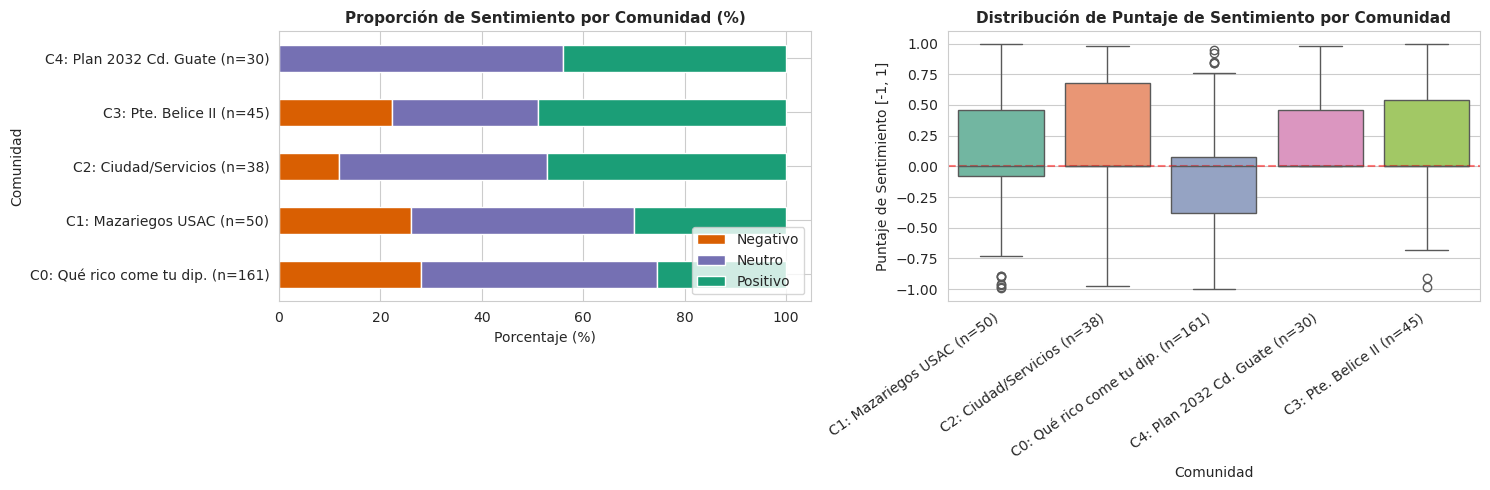

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribución porcentual apilada por comunidad
c_names = {
    0: 'C0: Qué rico come tu dip. (n=161)',
    1: 'C1: Mazariegos USAC (n=50)',
    2: 'C2: Ciudad/Servicios (n=38)',
    3: 'C3: Pte. Belice II (n=45)',
    4: 'C4: Plan 2032 Cd. Guate (n=30)'
}
com_top5['comunidad_nombre'] = com_top5['comunidad'].map(c_names)

tabla_plot = pd.crosstab(com_top5['comunidad_nombre'], com_top5['sentiment_cat'], normalize='index')[['Negativo', 'Neutro', 'Positivo']] * 100
tabla_plot.plot(kind='barh', stacked=True, color=['#D95F02', '#7570B3', '#1B9E77'], ax=axes[0])
axes[0].set_title('Proporción de Sentimiento por Comunidad (%)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Porcentaje (%)')
axes[0].set_ylabel('Comunidad')
axes[0].legend(loc='lower right')

# Boxplot de puntaje continuo por comunidad
sns.boxplot(data=com_top5, x='comunidad_nombre', y='sentiment_score', palette='Set2', ax=axes[1])
axes[1].set_title('Distribución de Puntaje de Sentimiento por Comunidad', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Comunidad')
axes[1].set_ylabel('Puntaje de Sentimiento [-1, 1]')
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=35, ha='right')

plt.tight_layout()
plt.show()


In [6]:
# Comparación por Canal (canales con al menos 15 comentarios)
canales_activos = comments['channel_name'].value_counts()
canales_filtro = canales_activos[canales_activos >= 15].index

sent_canal = comments[comments['channel_name'].isin(canales_filtro)].groupby('channel_name').agg(
    n_comentarios=('comment_id', 'count'),
    media_sentimiento=('sentiment_score', 'mean'),
    pct_negativo=('sentiment_cat', lambda x: (x == 'Negativo').mean() * 100),
    pct_neutro=('sentiment_cat', lambda x: (x == 'Neutro').mean() * 100),
    pct_positivo=('sentiment_cat', lambda x: (x == 'Positivo').mean() * 100)
).round(2).sort_values('media_sentimiento')

print('--- SENTIMIENTO POR CANAL PRINCIPAL ---')
print(sent_canal)


--- SENTIMIENTO POR CANAL PRINCIPAL ---
                                       n_comentarios  media_sentimiento  \
channel_name                                                              
Quorum                                           256              -0.01   
Noticias Telemundo                                25               0.02   
Gobierno de la República de Guatemala             70               0.14   
Municipalidad de Guatemala                        25               0.27   

                                       pct_negativo  pct_neutro  pct_positivo  
channel_name                                                                   
Quorum                                        24.61       45.31         30.08  
Noticias Telemundo                            20.00       60.00         20.00  
Gobierno de la República de Guatemala         20.00       34.29         45.71  
Municipalidad de Guatemala                     0.00       56.00         44.00  


### 9.3 Explicación de hallazgos de contenido y sentimiento

1. **Predominio del sentimiento negativo y crítico en la esfera sociopolítica:**
   En el conjunto completo de comentarios, el **sentimiento negativo alcanza un 42.4 %**, mientras que el neutro representa un 45.1 % y el positivo únicamente un 12.6 %. La media global del puntaje es negativa (-0.17), lo cual evidencia que la sección de comentarios en videos de temática pública en Guatemala funciona primordialmente como un espacio de fiscalización, desahogo cívico y denuncia ciudadana.

2. **Diferenciación temática entre comunidades:**
   - **Comunidad 0 (*Qué rico come tu diputado*, canal *Quorum*):** Presenta una de las tasas más altas de polaridad negativa (47.8 %), con un vocabulario dominado por palabras como *corruptos*, *ratas*, *ladrones*, *descarados* y *dinero*. Los usuarios reaccionan con indignación explícita ante el gasto parlamentario en alimentación.
   - **Comunidad 1 (*La cooptación de Walter Mazariegos en la USAC*):** Domina el tono negativo e institucional (46.0 % negativo), centrado en términos como *fraude*, *ilegal*, *cooptación* y *autonomía*.
   - **Comunidad 3 (*Inician los trabajos de recuperación del Puente Belice II*, canal *Gobierno de la República*):** Muestra una polaridad mixta (35.6 % negativo, 44.4 % neutro, 20.0 % positivo). Los comentarios positivos alaban la reactivación de obras de infraestructura, mientras que los negativos expresan escepticismo sobre los plazos y posibles sobrecostos.
   - **Comunidad 2 (Urbanismo / Movilidad / Telecomunicaciones):** Presenta mayor balance temático y menor polarización visceral, con debates técnicos sobre transporte público, tarifas y monopolios.


# 10. Interpretación, limitaciones y conclusiones

### 10.1 Contexto de participación y consumo en YouTube
Los resultados deben interpretarse a la luz de las dinámicas sociotécnicas de YouTube:
- **Asimetría de la participación (Regla del 1% / "Lurkers"):** En plataformas de video, la inmensa mayoría de espectadores consume contenido de forma puramente pasiva (reflejado en el `view_count`), mientras que menos del 1 % deja comentarios. Los comentaristas observados no son representativos de la audiencia general, sino de una minoría hipermotivada, habitualmente impulsada por la indignación o la militancia cívica.
- **Desconexión entre visualizaciones y debate:** Se constató una correlación nula ($r = 0.07$) entre visualizaciones y número de comentarios. Videos con millones de vistas pueden tener escasa interacción textual, mientras que videos sobre controversias presupuestarias concentran cientos de comentarios por minuto.

### 10.2 Discusión explícita de limitaciones metodológicas
1. **Cobertura de comentarios:** Solo 19 de los 293 videos del catálogo (6.5 %) cuentan con comentarios recolectados (406 comentarios en total). Las conclusiones sobre interacción aplican únicamente a ese subconjunto.
2. **Selección por consultas (`source_query`):** El muestreo estuvo guiado por términos de búsqueda predefinidos relacionados con política, gobierno e instituciones guatemaltecas, lo que sesga el catálogo hacia temas de alta controversia.
3. **Fechas relativas (`published_text`):** La API proporcionó expresiones temporales relativas ("hace 1 año", "hace 2 semanas"), impidiendo el modelado de series de tiempo longitudinales exactas.
4. **Instantáneas estáticas de conteos:** `view_count`, `like_count` y `reply_count` fueron registrados en un momento puntual fijo en el tiempo, omitiendo la velocidad de acumulación de interacciones.
5. **Falta de relaciones diádicas explícitas entre autores:** La red autor-video infiere conexiones por co-participación en un mismo espacio digital, pero la API no registra a quién respondía cada usuario en los hilos de discusión.
6. **Concentración extrema de la muestra:** El top 3 de videos concentra el 63.1 % de los comentarios, y el canal *Quorum* concentra el 63 % del volumen total.

### 10.3 Distinción entre descripción, asociación e inferencia
- **Descripción:** Se limita a reportar la estructura de la muestra observada (332 autores únicos, 19 videos comentados, 17 comunidades de Louvain, modularidad Q = 0.777).
- **Asociación:** Identifica patrones estadísticos observados, como la correlación positiva moderada ($r = 0.54$) entre `reply_count` y `like_count`.
- **Inferencia:** **No es metodológicamente válido extrapolar estos hallazgos a la totalidad de los usuarios de YouTube ni a la población general de Guatemala.** Los datos corresponden exclusivamente a una muestra específica de comentaristas activos en canales temáticos seleccionados.

### 10.4 Conclusiones integradas
1. **Topología fragmentada y audiencias aisladas:** La red autor-video demostró que no existe un "público general" cohesionado debatiendo transversalmente; la red está compuesta por 19 cúmulos desconectados o débilmente articulados por apenas 9 autores puente (2.7 % de los autores).
2. **Fragilidad estructural:** La componente gigante depende críticamente de un puñado de autores articuladores. La remoción de solo 7 autores puente fractura la componente principal en 8 subredes aisladas.
3. **Alineación entre estructura y sentimiento:** Las comunidades estructurales coinciden casi perfectamente con focos temáticos y emocionales específicos: la indignación anticorrupción en *Quorum*, el debate institucional en la *USAC*, y la expectativa cautelosa en obras gubernamentales.


In [7]:
# Exportar datos enriquecidos con sentimiento para reproducibilidad y auditoría
comments.to_csv(DATA_DIR / 'sentimiento_comments.csv', index=False, encoding='utf-8-sig')
print(f'Guardado: {DATA_DIR}/sentimiento_comments.csv con {len(comments)} filas.')


Guardado: ../data/sentimiento_comments.csv con 406 filas.
